# Initialization

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter

from vzr_p2.kv_utils import parse_kv_file
from vzr_p2.notebook import disp, init, savefig

init()
sns.set_style("whitegrid")

In [26]:
df_results = parse_kv_file("results/hpc")
df_results["size_w2"] = df_results["size_w"].pow(2)
df_results["impl"] = pd.Categorical(
    df_results["impl"], categories=["seq", "omp", "cuda"], ordered=True
)
disp(df_results)
df_results_agg = disp(
    df_results.groupby(
        [x for x in df_results.columns if not x.startswith("t_")],
        dropna=False,
    ).mean()
)
df_results_agg_by_size_and_impl = disp(
    df_results.pipe(
        lambda df: df.drop(
            columns=[
                x
                for x in df.columns
                if not (x.startswith("t_") or x in ("impl", "size_w", "size_w2"))
            ]
        )
    )
    .pipe(
        lambda df: df.groupby(
            [x for x in df.columns if not x.startswith("t_")],
            dropna=False,
        )
    )
    .mean()
)

,opt,impl,size_w,size_h,kernel_size,precision,simd,toroid_impl,steps,dt,...,t_steps,t_download,t_free,t_work_total,t_total,threads,kernel,toroid,unroll,size_w2
0,3,seq,256,256,26,64,y,halo,100,0.1,...,1.101968,2.309680e-07,0.000188,1.101968,1.102248,NaN,NaN,NaN,NaN,65536
1,3,seq,256,256,26,64,y,halo,100,0.1,...,1.095743,1.708977e-07,0.000192,1.095743,1.096025,NaN,NaN,NaN,NaN,65536
2,3,seq,256,256,26,64,y,halo,100,0.1,...,1.095870,7.078052e-08,0.000168,1.095870,1.096125,NaN,NaN,NaN,NaN,65536
3,3,seq,256,256,26,64,y,halo,100,0.1,...,1.098322,4.097819e-07,0.000190,1.098323,1.098598,NaN,NaN,NaN,NaN,65536
4,3,seq,256,256,26,64,y,halo,100,0.1,...,1.100100,4.982576e-08,0.000196,1.100100,1.100381,NaN,NaN,NaN,NaN,65536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,3,cuda,4096,4096,26,32,NaN,NaN,100,0.1,...,0.612810,5.436806e-03,0.000943,0.624211,0.762427,32x32,fused,mod,NaN,16777216
1046,3,cuda,4096,4096,26,32,NaN,NaN,100,0.1,...,0.612788,5.303947e-03,0.000893,0.623734,0.757882,32x32,fused,mod,NaN,16777216
1047,3,cuda,4096,4096,26,32,NaN,NaN,100,0.1,...,0.612807,5.459740e-03,0.000968,0.623877,0.758803,32x32,fused,mod,NaN,16777216
1048,3,cuda,4096,4096,26,32,NaN,NaN,100,0.1,...,0.612784,5.358991e-03,0.000968,0.623756,0.756940,32x32,fused,mod,NaN,16777216


t_init  \
opt impl size_w size_h kernel_size precision simd toroid_impl steps dt  threads kernel  toroid  unroll size_w2              
3   seq  256    256    26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    65536     0.000087   
         512    512    26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    262144    0.000191   
         1024   1024   26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    1048576   0.000224   
         2048   2048   26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    4194304   0.000337   
         4096   4096   26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    16777216  0.000321   
...                                                                                                                   ...   
    cuda 4096   4096   26          64        NaN  NaN         100   0.1 64x16   default mod     NaN    16777216  0.147527   
                                                                                fused   bitwise y      16777216  0.136651   
                                                                                        mod     NaN    16777216  0.143373   
                                                                                shared  bitwise y      16777216  0.140149   
                                                                                        mod     NaN    16777216  0.142558   

                                                                                                                     t_upload  \
opt impl size_w size_h kernel_size precision simd toroid_impl steps dt  threads kernel  toroid  unroll size_w2                  
3   seq  256    256    26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    65536     3.622845e-08   
         512    512    26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    262144    5.001202e-08   
         1024   1024   26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    1048576   3.594905e-08   
         2048   2048   26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    4194304   3.790483e-08   
         4096   4096   26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    16777216  4.228205e-08   
...                                                                                                                       ...   
    cuda 4096   4096   26          64        NaN  NaN         100   0.1 64x16   default mod     NaN    16777216  1.120418e-02   
                                                                                fused   bitwise y      16777216  1.099630e-02   
                                                                                        mod     NaN    16777216  1.105658e-02   
                                                                                shared  bitwise y      16777216  1.455062e-02   
                                                                                        mod     NaN    16777216  1.105963e-02   

                                                                                                                    t_steps  \
opt impl size_w size_h kernel_size precision simd toroid_impl steps dt  threads kernel  toroid  unroll size_w2                
3   seq  256    256    26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    65536       1.098401   
         512    512    26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    262144      4.376653   
         1024   1024   26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    1048576    17.533502   
         2048   2048   26          64        y    halo        100   0.1 NaN     NaN     NaN     NaN    4194304    70.254104   
         4096   4096   26          64        y   

t_init      t_upload     t_steps    t_download  \
impl size_w size_w2                                                      
seq  256    65536     0.000087  3.622845e-08    1.098401  1.864508e-07   
     512    262144    0.000191  5.001202e-08    4.376653  2.301298e-07   
     1024   1048576   0.000224  3.594905e-08   17.533502  2.148561e-07   
     2048   4194304   0.000337  3.790483e-08   70.254104  1.683831e-07   
     4096   16777216  0.000321  4.228205e-08  281.773240  2.665445e-07   
omp  256    65536     0.000098  3.594905e-08    0.032378  6.426126e-08   
     512    262144    0.000276  4.023314e-08    0.103378  6.407499e-08   
     1024   1048576   0.000285  3.799796e-08    0.379092  5.792826e-08   
     2048   4194304   0.000769  3.399327e-08    1.424483  1.340173e-07   
     4096   16777216  0.000702  3.604218e-08    5.591378  1.781620e-07   
cuda 256    65536     0.134934  4.231087e-04    0.005510  5.250953e-05   
     512    262144    0.134516  5.402524e-04    0.020027  2.612401e-04   
     1024   1048576   0.138862  9.198271e-04    0.065152  8.988945e-04   
     2048   4194304   0.139989  2.509322e-03    0.248528  2.179076e-03   
     4096   16777216  0.140360  8.565727e-03    0.988068  5.301907e-03   

                        t_free  t_work_total     t_total  
impl size_w size_w2                                       
seq  256    65536     0.000187      1.098401    1.098675  
     512    262144    0.000325      4.376653    4.377169  
     1024   1048576   0.001189     17.533502   17.534915  
     2048   4194304   0.003685     70.254105   70.258126  
     4096   16777216  0.006268    281.773241  281.779830  
omp  256    65536     0.000202      0.032378    0.032678  
     512    262144    0.000366      0.103378    0.104021  
     1024   1048576   0.001381      0.379092    0.380758  
     2048   4194304   0.004600      1.424483    1.429852  
     4096   16777216  0.016576      5.591379    5.608656  
cuda 256    65536     0.000217      0.005986    0.141137  
     512    262144    0.000445      0.020829    0.155790  
     1024   1048576   0.000969      0.066970    0.206801  
     2048   4194304   0.001186      0.253217    0.394392  
     4096   16777216  0.001558      1.001935    1.143853

# Scaling comparison

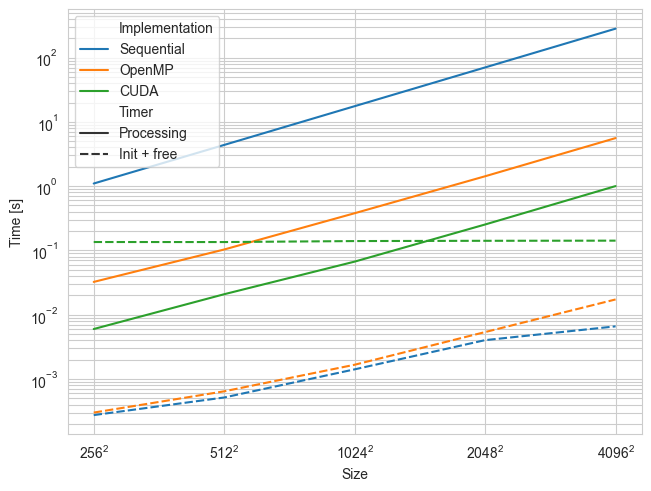

In [31]:
df = df_results_agg_by_size_and_impl.reset_index()
df = pd.concat(
    [
        df.assign(kind="work", t=df["t_work_total"]),
        df.assign(kind="init", t=df["t_total"] - df["t_work_total"]),
    ]
)
df["kind"] = pd.Categorical(df["kind"], categories=["work", "init"], ordered=True)


def sqrt_squared_formatter(x, pos):
    if x < 0:
        return ""
    r = np.sqrt(x)
    if np.isclose(r, round(r)):
        r = round(r)
    return rf"$\mathregular{{{r}}}^\mathregular{{2}}$"


fig, ax = plt.subplots(layout="compressed")
sns.lineplot(
    df,
    ax=ax,
    x=df["size_w2"].rename("Size"),
    y=df["t"].rename("Time [s]"),
    hue=(
        df["impl"]
        .rename("Implementation")
        .map({"seq": "Sequential", "omp": "OpenMP", "cuda": "CUDA"})
    ),
    style=(
        df["kind"].rename("Timer").map({"init": "Init + free", "work": "Processing"})
    ),
)
ax.grid(True, "both", "y")
ax.set_xscale("log", base=2)
ax.set_xticks(df["size_w2"].unique())
ax.xaxis.set_major_formatter(FuncFormatter(sqrt_squared_formatter))
ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_yscale("log")

savefig(fig, "fig/scaling.pdf")